In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense , Dropout
from tensorflow.keras.callbacks import EarlyStopping
from IPython.display import FileLink

In [2]:
df = pd.read_csv("IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df['review'].value_counts

<bound method IndexOpsMixin.value_counts of 0        One of the other reviewers has mentioned that ...
1        A wonderful little production. <br /><br />The...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: str>

In [5]:
df['labels'] = df['sentiment'].map({'positive':1,'negative':0})

In [6]:
# Text Cleaning Function
import re
def clean_text(text):
    text = re.sub(r"<.*?>", "", text)      # Remove HTML tags
    text = re.sub(r"[^a-zA-Z ]", "", text) # Remove special characters
    return text.lower()

In [7]:
df['review'] = df['review'].apply(clean_text)

In [8]:
max_words = 10000
max_len = 50
"""OOV means:
Out Of Vocabulary
If a new word appears that wasn't seen during training"""
tokenizer = Tokenizer(num_words=max_words,oov_token="<OOV>")
tokenizer.fit_on_texts(df['review']) 

X = tokenizer.texts_to_sequences(df['review'])
X = pad_sequences(X,maxlen=max_len,padding='post')
y = df['labels'].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
model = Sequential([
    Embedding(input_dim=max_words,output_dim=32),
    LSTM(64,return_sequences=False),
    Dropout(0.3),
    Dense(32,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [11]:
model.compile(optimizer='adam',loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.7688 - loss: 0.4697 - val_accuracy: 0.8163 - val_loss: 0.4070
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8464 - loss: 0.3532 - val_accuracy: 0.8152 - val_loss: 0.4013
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8774 - loss: 0.2923 - val_accuracy: 0.8077 - val_loss: 0.4261
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9048 - loss: 0.2340 - val_accuracy: 0.8077 - val_loss: 0.4715
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9286 - loss: 0.1830 - val_accuracy: 0.8000 - val_loss: 0.6466


In [14]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {acc:.4f}")

model.save('best_model.h5')
display(FileLink('best_model.h5'))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8170 - loss: 0.4032



Test Accuracy: 0.8170


c:\Users\inter\OneDrive\Documents\Deep learning\Sentiment_Analysis(RNN)\best_model.h5

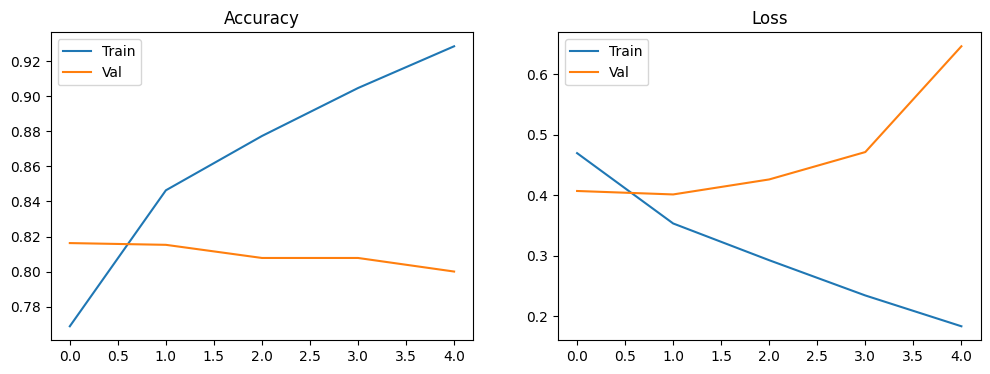

In [15]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss"); plt.legend()
plt.show()

In [16]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = model.predict(padded)[0][0]
    label = "Positive 😊" if prob > 0.5 else "Negative 😞"
    print(f"{label} (confidence: {prob:.2f})")

predict_sentiment("This movie was absolutely amazing, I loved every second!")
predict_sentiment("Terrible film, complete waste of time.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Positive 😊 (confidence: 0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Negative 😞 (confidence: 0.03)


In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)
from tensorflow.keras.models import load_model

best_model = load_model('best_model.keras')

loss, accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/10
 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8872 - loss: 0.2729
Epoch 1: val_loss improved from None to 0.35888, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8817 - loss: 0.2830 - val_accuracy: 0.8429 - val_loss: 0.3589
Epoch 2/10
 996/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9186 - loss: 0.2100
Epoch 2: val_loss did not improve from 0.35888
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9077 - loss: 0.2288 - val_accuracy: 0.8299 - val_loss: 0.4114
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9368 - loss: 0.1663
Epoch 3: val_loss did not improve from 0.35888
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9299 - loss: 0.1800 - val_accuracy: 0.8202 - val_loss: 0.5108


c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8169 - loss: 0.4444
Test Accuracy: 0.8169
